# Taller 2 : Fluidos incompresibles

In [29]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

In [30]:
def funcion_shacham(rugosidad, D_interno, Reynolds):
    proporcion = rugosidad / D_interno
    
    A = ((proporcion/3.71)+(14.5/Reynolds))
    B = (5.02/Reynolds) * np.log10(A)
    C = (proporcion/3.71) - B
    D = -2 * np.log10(C)
    result = D**(-2)
    
    return result

def funcion_f_colebrook(diametro, rugosidad):
    result = 1.14 + (2 * (np.log10(diametro/rugosidad)))
    f = (1/result)**2
    return f

In [31]:
def sistema(vars, rugosidad, D, L, H, K, nu, g):
    f, V = vars
    Re = (V * D) / nu
    proporcion = rugosidad / D

    # ---- Shacham ----
    A = (proporcion / 3.71) + (14.5 / Re)
    B = (5.02 / Re) * np.log10(A)
    C = (proporcion / 3.71) - B
    
    if C <= 0:
        return [1e6, 1e6]
    
    f_shacham = (-2 * np.log10(C))**(-2)

    eq1 = H - ((f * (L/D) + K) * (V**2) / (2*g))
    eq2 = f - f_shacham

    return [eq1, eq2]

Un tanque A esta comunicado a un tanque B mediante:

- Una tubería de diámetro D, longitud L y rugosidad absoluta e.
- La diferencia de nivel entre los dos tanques es H.

Calcular el gasto Q que puede pasar por la tubería en función de las características de las tuberías y la diferencia de nivel. 

- a) Analizar el efecto de las perdidas locales v.s pérdidas mayores.
- b) Calcular Q para D= 6 in L=1.78 km e=0.1 mm H= 60 m, considerando y sin considerar perdidas locales. Asuma que la temperatura del agua es 15°C.

In [32]:
rugosidad = 40e-06
D_interno = 1.049 * 0.0254
razon_LD = 10
L = D_interno * razon_LD    # m
reynolds = 1e+05

K = 1.5

LD_list = [0.01, 0.1, 1, 10, 100, 1000]

# ---- Cálculo ----
rows = []
f = funcion_shacham(rugosidad, D_interno ,reynolds)

for LD in LD_list:
    hf = f * LD           # proporcional a pérdidas mayores
    hl = K                # proporcional a pérdidas locales
    
    pct_local = hl / (hf + hl) * 100
    pct_major = hf / (hf + hl) * 100
    
    rows.append({
        "L/D": LD,
        "f_D (Shacham)": f,
        "perdidas mayores (∝ f·L/D)": hf,
        "perdidas locales (∝ K)": hl,
        "% perdidas locales": pct_local,
        "% perdidas mayores": pct_major
    })

df = pd.DataFrame(rows)
display(df)

,L/D,f_D (Shacham),perdidas mayores (∝ f·L/D),perdidas locales (∝ K),% perdidas locales,% perdidas mayores
0,0.01,0.023735,0.000237,1.5,99.984179,0.015821
1,0.10,0.023735,0.002374,1.5,99.842014,0.157986
2,1.00,0.023735,0.023735,1.5,98.442288,1.557712
3,10.00,0.023735,0.237354,1.5,86.338189,13.661811
4,100.00,0.023735,2.373540,1.5,38.724265,61.275735
5,1000.00,0.023735,23.735402,1.5,5.944030,94.055970


In [33]:
D = 6 * (1/39.3701)     # m (6 in)
L = 1.78 * 1000         # m
rugosidad = 1e-4        # m
delta_H = 60            # m
g = 9.81
nu = 1.14e-6            # m^2/s

K = 0                  # sin pérdidas locales

f_0 = 0.02
V_0 = 2.0

sol = fsolve(
    sistema,
    [f_0, V_0],
    args=(rugosidad, D, L, delta_H, K, nu, g),
    xtol=1e-10,
    maxfev=5000
)

f, V = sol

A = np.pi * D**2 / 4
Q = V * A

print(f"factor de fricción de darcy = {f:,.5f}")
print(f"Velocidad = {V:,.5f} m/s")
print(f"caudal = {Q:,.5f} m^3/s")

Re = (V * D) / nu
print(f"Re = {Re:,.2e}")

factor de fricción de darcy = 0.01901
Velocidad = 2.30256 m/s
caudal = 0.04200 m^3/s
Re = 3.08e+05


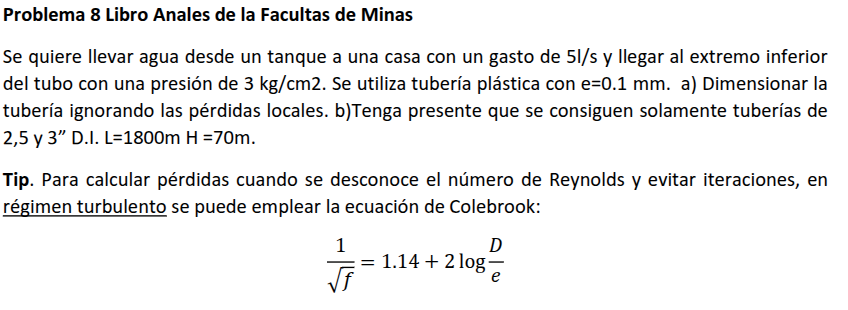

In [ ]:
#   a).

Q = 5e-3
L = 1800
e = 1e-4
g = 9.81
nu = 1.14e-6

h_perdidas = 40  # m


def ecuacion(D):
    A = np.pi * D**2 / 4
    V = Q / A
    Re = V * D / nu
    
    f = funcion_f_colebrook(D, e)
    
    hf = f * (L/D) * (V**2 / (2*g))
    
    return hf - h_perdidas

D0 = 0.1

D_sol = fsolve(ecuacion, D0)[0]

print(f"diametro necesario para el flujo = {D_sol:,.4f} m")
print(f"diametro necesario para el flujo en pulgadas = {D_sol * 39.37:,.4f} in")

#   b).



diametro necesario para el flujo = 0.0723 m
diametro necesario para el flujo en pulgadas = 2.8466 in


In [37]:
D1 = 3 * 0.0254
D2 = 2.5 * 0.0254

def f_colebrook(D):
    return (1 / (1.14 + 2*np.log10(D/e)))**2

def perdida(L1):
    L2 = L - L1
    
    f1 = funcion_f_colebrook(D, e)
    f2 = funcion_f_colebrook(D, e)
    
    V1 = Q / (np.pi * D1**2 / 4)
    V2 = Q / (np.pi * D2**2 / 4)
    
    hf1 = f1 * (L1/D1) * (V1**2 / (2*g))
    hf2 = f2 * (L2/D2) * (V2**2 / (2*g))
    
    return (hf1 + hf2) - h_perdidas

L1_sol = fsolve(perdida, 1000)[0]
L2_sol = L - L1_sol

print(f'tuberias diametro 3": {L1_sol:,.4f}, diametro 2.5": {L2_sol:,.4f}')

tuberias diametro 3": 1,126.2415, diametro 2.5": 673.7585
